<a href="https://colab.research.google.com/github/elKiruvi/benchmark-bow-vs-embeddings/blob/main/benchmark_bow_vs_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark Bbow vs Embeddings


### Instalaciones y configuración


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import sys
import psutil
import os

warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Paleta de colores para visualizaciones
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

### Implementación y análisis

#### 1.1 Carga + Pipeline BoW

In [ ]:
# ----------------------------------------------------------
# 1.1  Se cargan las 20 categorías completas
# ----------------------------------------------------------
print("\n Cargando fetch_20newsgroups (20 categorías)...")

train_data = fetch_20newsgroups(
    subset='train',
    random_state=42
)
test_data = fetch_20newsgroups(
    subset='test',
    random_state=42
)

print(f"  Documentos train : {len(train_data.data):>6,}")
print(f"  Documentos test  : {len(test_data.data):>6,}")
print(f"  Categorías       : {len(train_data.target_names)}")


 Cargando fetch_20newsgroups (20 categorías)...
  Documentos train : 11,314
  Documentos test  :  7,532
  Categorías       : 20


In [ ]:
# ----------------------------------------------------------
# 1.1.2  Función auxiliar para entrenar y evaluar
# ----------------------------------------------------------
def entrenar_y_evaluar(min_df, max_df, max_features):
    """
    Pipeline CountVectorizer → LogisticRegression,
    entrena y devuelve accuracy + tamaño del vocabulario.

    Parámetros
    ----------
    min_df       : frecuencia mínima de documento (int o float)
    max_df       : frecuencia máxima de documento (int o float)
    max_features : límite superior del vocabulario (int o None)

    Retorna
    -------
    accuracy  : float
    vocab_size: int
    """
    pipe = Pipeline([
        ('vect', CountVectorizer(
            lowercase=True,
            stop_words='english',
            min_df=min_df,
            max_df=max_df,
            max_features=max_features
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe.fit(train_data.data, train_data.target)
    y_pred = pipe.predict(test_data.data)
    acc        = accuracy_score(test_data.target, y_pred)
    vocab_size = len(pipe.named_steps['vect'].vocabulary_)
    return acc, vocab_size

#### 1.2 Experimentos `min_df`, `max_df`, `max_features`

In [ ]:
# ----------------------------------------------------------
# 1.2  Grilla de experimentos
# ----------------------------------------------------------
print("\n Ejecutando experimentos...")

experimentos = [
    # (min_df, max_df, max_features, etiqueta)
    (1,  1.0,   None,   "min_df=1,  max_df=1.0,  max_feat=None"),
    (2,  1.0,   None,   "min_df=2,  max_df=1.0,  max_feat=None"),
    (5,  1.0,   None,   "min_df=5,  max_df=1.0,  max_feat=None"),
    (10, 1.0,   None,   "min_df=10, max_df=1.0,  max_feat=None"),
    (2,  0.95,  None,   "min_df=2,  max_df=0.95, max_feat=None"),
    (2,  0.80,  None,   "min_df=2,  max_df=0.80, max_feat=None"),
    (2,  0.95,  5_000,  "min_df=2,  max_df=0.95, max_feat=5k"),
    (2,  0.95,  20_000, "min_df=2,  max_df=0.95, max_feat=20k"),
    (2,  0.95,  50_000, "min_df=2,  max_df=0.95, max_feat=50k"),
    (2,  0.95,  100_000,"min_df=2,  max_df=0.95, max_feat=100k"),
]

resultados_exp1 = []

print(f"\n  {'Configuración':<45} {'Vocab':>8} {'Accuracy':>10}")
print(f"  {'-'*65}")

for min_df, max_df, max_feat, label in experimentos:
    acc, vocab = entrenar_y_evaluar(min_df, max_df, max_feat)
    resultados_exp1.append({
        'label'    : label,
        'min_df'   : min_df,
        'max_df'   : max_df,
        'max_feat' : max_feat if max_feat else 'None',
        'vocab'    : vocab,
        'accuracy' : acc
    })
    print(f"  {label:<45} {vocab:>8,} {acc:>10.4f}")

df_exp1 = pd.DataFrame(resultados_exp1)


 Ejecutando experimentos...

  Configuración                                    Vocab   Accuracy
  -----------------------------------------------------------------
  min_df=1,  max_df=1.0,  max_feat=None          129,796     0.8044
  min_df=2,  max_df=1.0,  max_feat=None           56,126     0.8016
  min_df=5,  max_df=1.0,  max_feat=None           25,636     0.7973
  min_df=10, max_df=1.0,  max_feat=None           15,291     0.7925
  min_df=2,  max_df=0.95, max_feat=None           56,123     0.8023
  min_df=2,  max_df=0.80, max_feat=None           56,123     0.8023
  min_df=2,  max_df=0.95, max_feat=5k              5,000     0.7621
  min_df=2,  max_df=0.95, max_feat=20k            20,000     0.7965
  min_df=2,  max_df=0.95, max_feat=50k            50,000     0.8012
  min_df=2,  max_df=0.95, max_feat=100k           56,123     0.8023


#### 1.3 Visualizaciones

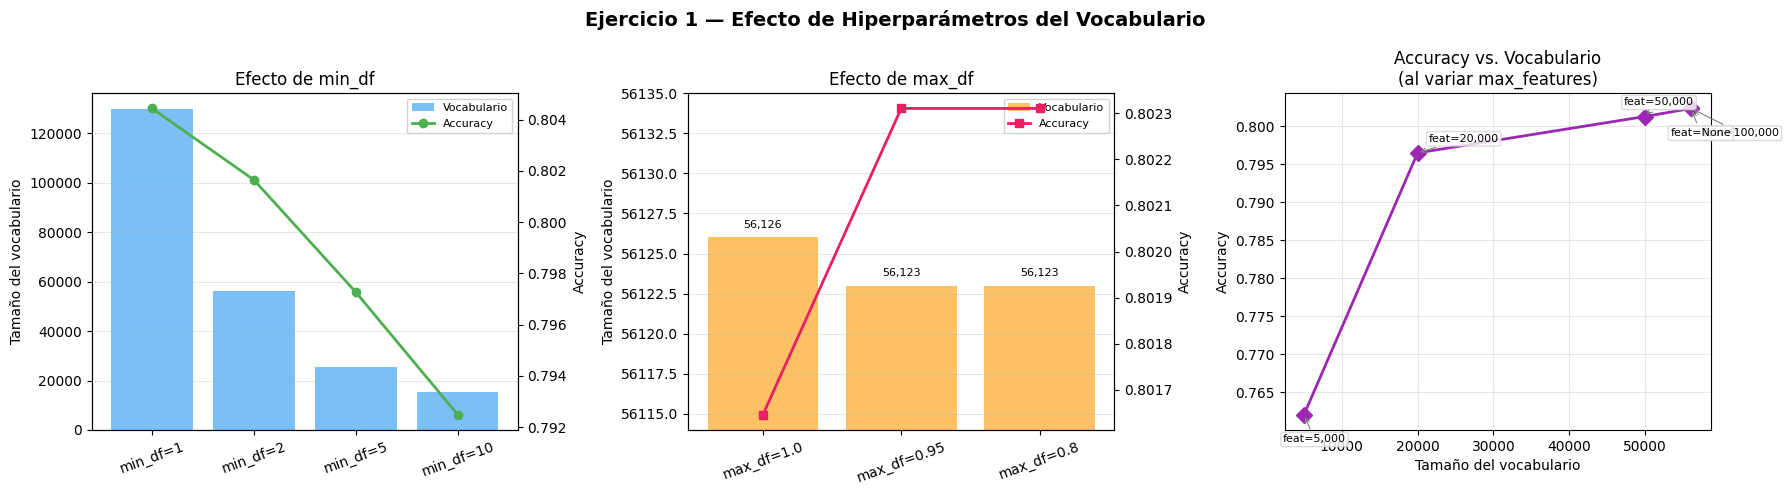

In [ ]:
# ----------------------------------------------------------
# 1.3  Visualización
# ----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ejercicio 1 — Efecto de Hiperparámetros del Vocabulario',
             fontsize=14, fontweight='bold')

# ── Subplot A: Efecto de min_df ──────────────────────────────────
mask_mindf = df_exp1['max_df'] == 1.0
sub_a = df_exp1[mask_mindf & (df_exp1['max_feat'] == 'None')]

ax  = axes[0]
ax2 = ax.twinx()
x   = np.arange(len(sub_a))

bars = ax.bar(x, sub_a['vocab'], color=COLORS[0], alpha=0.6, label='Vocabulario')
line, = ax2.plot(x, sub_a['accuracy'], 'o-', color=COLORS[1],
                 linewidth=2, label='Accuracy')

ax.set_xticks(x)
ax.set_xticklabels([f"min_df={v}" for v in sub_a['min_df']], rotation=20)
ax.set_ylabel('Tamaño del vocabulario')
ax2.set_ylabel('Accuracy')
ax.set_title('Efecto de min_df')

# Leyenda combinada
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3)

# ── Subplot B: Efecto de max_df ──────────────────────────────────
mask_maxdf = df_exp1['min_df'] == 2
sub_b = df_exp1[mask_maxdf & (df_exp1['max_feat'] == 'None')]

ax  = axes[1]
ax2 = ax.twinx()
x   = np.arange(len(sub_b))

bars2 = ax.bar(x, sub_b['vocab'], color=COLORS[2], alpha=0.6, label='Vocabulario')
line2, = ax2.plot(x, sub_b['accuracy'], 's-', color=COLORS[3],
                  linewidth=2, label='Accuracy')

# Zoom en eje vocab para que las pequeñas diferencias sean visibles
v_min = sub_b['vocab'].min()
v_max = sub_b['vocab'].max()
margen = (v_max - v_min) * 3
ax.set_ylim(max(0, v_min - margen), v_max + margen)

# Etiquetas de valor encima de cada barra
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + margen * 0.05,
            f'{int(h):,}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"max_df={v}" for v in sub_b['max_df']], rotation=20)
ax.set_ylabel('Tamaño del vocabulario')
ax2.set_ylabel('Accuracy')
ax.set_title('Efecto de max_df')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3)

# ── Subplot C: Accuracy vs. Vocabulario (max_features) ──────────
mask_feat = (df_exp1['min_df'] == 2) & (df_exp1['max_df'] == 0.95)
sub_c = df_exp1[mask_feat].copy()
sub_c['max_feat_num'] = sub_c['max_feat'].apply(
    lambda v: 200_000 if v == 'None' else int(v))
sub_c = sub_c.sort_values('max_feat_num')

ax = axes[2]
ax.plot(sub_c['vocab'], sub_c['accuracy'],
        'D-', color=COLORS[4], linewidth=2, markersize=8)

# Posiciones alternas
offset_list = [(-15, -20), (8, 8), (-15, 8), (8, -20), (-15, -20)]

for i, (_, row) in enumerate(sub_c.iterrows()):
    dx, dy = offset_list[i % len(offset_list)]
    label  = 'None' if row['max_feat'] == 'None' \
             else f"{int(row['max_feat_num']):,}"
    ax.annotate(
        f"feat={label}",
        xy=(row['vocab'], row['accuracy']),
        xytext=(dx, dy), textcoords='offset points',
        fontsize=8,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='lightgray', alpha=0.8)
    )

ax.set_xlabel('Tamaño del vocabulario')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs. Vocabulario\n(al variar max_features)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ejercicio1_hiperparametros.png', dpi=150, bbox_inches='tight')
plt.show()

#### 1.4 Configuración óptima

In [ ]:
# ----------------------------------------------------------
# 1.4  Identificar la configuración óptima
# ----------------------------------------------------------
print("\n Configuración óptima:")

mejor = df_exp1.loc[df_exp1['accuracy'].idxmax()]
print(f"\n  {mejor['label']}")
print(f"     → Accuracy   : {mejor['accuracy']:.4f}")
print(f"     → Vocabulario: {mejor['vocab']:,} tokens")


 Configuración óptima:

  min_df=1,  max_df=1.0,  max_feat=None
     → Accuracy   : 0.8044
     → Vocabulario: 129,796 tokens


  **Conclusiones:**
  * A pesar de que el mejor Accuracy es con `min_df`= 1, `max_df`= 1.0 y `max_feat`= None, se podría elegir los modelos con `min_df`= 2, `max_df`=0.95 y `max_feat`= 50k o 100k porque tienen un desempeño similar, pero con un vocabulario mucho menor.
  * min_df ≥ 2  elimina ruido sin pérdida significativa de accuracy.
  * max_df = 0.95 elimina términos omnipresentes sin valor discriminativo.
  * max_features: a partir de 50k el accuracy se estabiliza;
  vocabularios más grandes no justifican el costo de memoria.

### Efecto de n-gramas

#### 2.1 N-gramas

In [ ]:
# ----------------------------------------------------------
# 2.1  Definir configuraciones de n-gramas
# ----------------------------------------------------------
configuraciones_ngrama = [
    ((1, 1), "Solo unigramas\n(1,1)"),
    ((1, 2), "Unigramas + Bigramas\n(1,2)"),
    ((1, 3), "Uni + Bi + Trigramas\n(1,3)"),
    ((2, 2), "Solo bigramas\n(2,2)"),
    ((2, 3), "Bi + Trigramas\n(2,3)"),
    ((3, 3), "Solo trigramas\n(3,3)"),
]

#### 2.2 Evaluaciones

In [ ]:
# ----------------------------------------------------------
# 2.2  Evaluar cada configuración
# ----------------------------------------------------------
print("\n Evaluando configuraciones...\n")
print(f"  {'N-grama':<30} {'Vocabulario':>12} {'Accuracy':>10}")
print(f"  {'-'*55}")

resultados_ngrama = []

for ngram_range, label in configuraciones_ngrama:
    pipe = Pipeline([
        ('vect', CountVectorizer(
            lowercase=True,
            stop_words='english',
            ngram_range=ngram_range,
            min_df=2,
            max_df=0.95
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe.fit(train_data.data, train_data.target)
    y_pred = pipe.predict(test_data.data)
    acc   = accuracy_score(test_data.target, y_pred)
    vocab = len(pipe.named_steps['vect'].vocabulary_)
    clean_label = label.replace('\n', ' ')
    print(f"  {clean_label:<30} {vocab:>12,} {acc:>10.4f}")
    resultados_ngrama.append({
        'label'  : label,
        'ngram'  : str(ngram_range),
        'vocab'  : vocab,
        'accuracy': acc
    })

df_ngrama = pd.DataFrame(resultados_ngrama)


 Evaluando configuraciones...

  N-grama                         Vocabulario   Accuracy
  -------------------------------------------------------
  Solo unigramas (1,1)                 56,123     0.8023
  Unigramas + Bigramas (1,2)          305,506     0.8125
  Uni + Bi + Trigramas (1,3)          531,350     0.8113
  Solo bigramas (2,2)                 249,383     0.6928
  Bi + Trigramas (2,3)                475,227     0.6767
  Solo trigramas (3,3)                225,844     0.5648


#### 2.3 Visualizaciones


 Graficando...


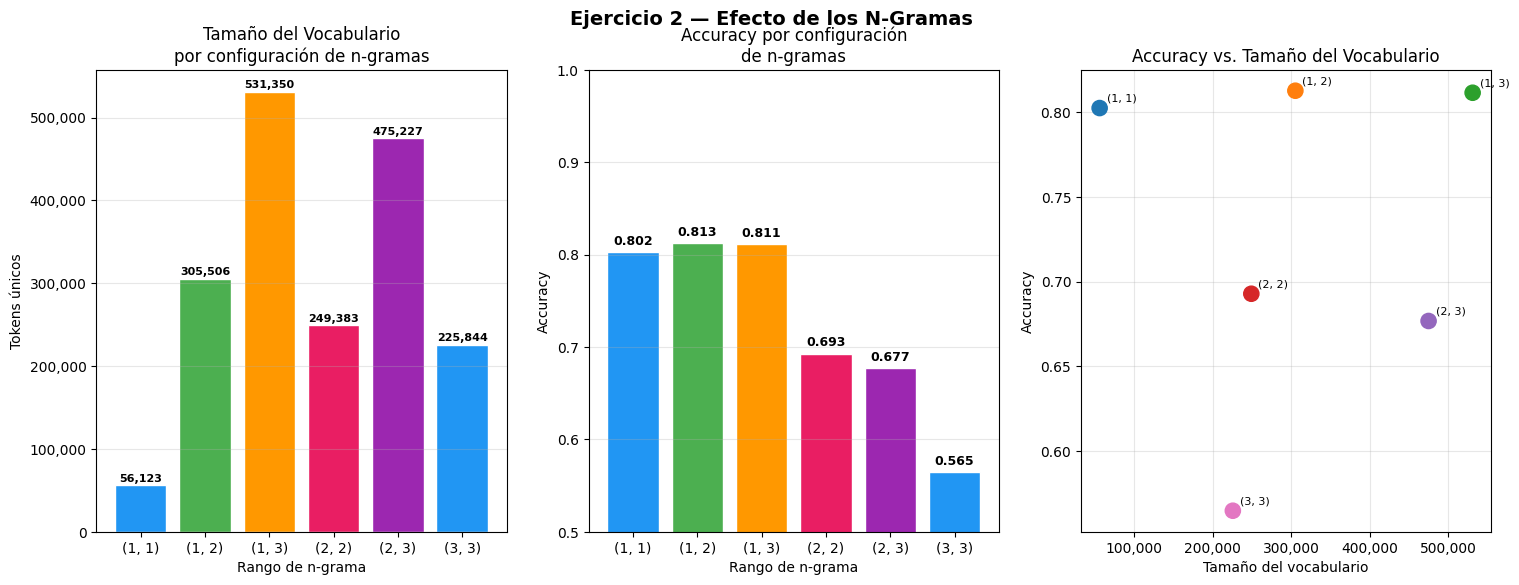

In [ ]:
# ----------------------------------------------------------
# 2.3  Visualización en 3 subplots
# ----------------------------------------------------------
print("\n Graficando...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ejercicio 2 — Efecto de los N-Gramas', fontsize=14, fontweight='bold')

labels_cortos = [r['ngram'] for r in resultados_ngrama]
vocabs        = df_ngrama['vocab'].values
accuracies    = df_ngrama['accuracy'].values

# ── Subplot 1: Vocabulario por configuración ──
ax = axes[0]
bars = ax.bar(labels_cortos, vocabs, color=COLORS[:len(labels_cortos)], edgecolor='white')
ax.set_title('Tamaño del Vocabulario\npor configuración de n-gramas')
ax.set_ylabel('Tokens únicos')
ax.set_xlabel('Rango de n-grama')
for bar, v in zip(bars, vocabs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'{v:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Subplot 2: Accuracy por configuración ──
ax = axes[1]
bars2 = ax.bar(labels_cortos, accuracies, color=COLORS[:len(labels_cortos)], edgecolor='white')
ax.set_title('Accuracy por configuración\nde n-gramas')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Rango de n-grama')
ax.set_ylim(0.5, 1.0)
for bar, a in zip(bars2, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{a:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# ── Subplot 3: Accuracy vs. Vocabulario ──
ax = axes[2]
colores_ngrama = plt.cm.tab10(np.linspace(0, 0.6, len(vocabs)))
sc = ax.scatter(vocabs, accuracies, c=colores_ngrama, s=120, zorder=3)

for i, (v, a, lbl) in enumerate(zip(vocabs, accuracies, labels_cortos)):
    ax.annotate(lbl, xy=(v, a), xytext=(5, 5),
                textcoords='offset points', fontsize=8)
ax.set_xlabel('Tamaño del vocabulario')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs. Tamaño del Vocabulario')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(alpha=0.3)

#### 2.4 Análisis

In [ ]:
print("\n Análisis de saturación:")

df_principales = df_ngrama[df_ngrama['ngram'].isin(["(1, 1)", "(1, 2)", "(1, 3)"])].copy()
df_principales = df_principales.sort_values('vocab')

for i in range(1, len(df_principales)):
    prev = df_principales.iloc[i - 1]
    curr = df_principales.iloc[i]
    delta_vocab = curr['vocab'] - prev['vocab']
    delta_acc   = curr['accuracy'] - prev['accuracy']
    print(f"\n  Paso {prev['ngram']} → {curr['ngram']}:")
    print(f"    Δ Vocabulario  : +{delta_vocab:,} tokens  "
          f"({delta_vocab/prev['vocab']*100:.1f}% más)")
    print(f"    Δ Accuracy     : {delta_acc:+.4f}")
    if delta_acc > 0:
        eficiencia = delta_acc / (delta_vocab / 1000)
        print(f"    Eficiencia     : {eficiencia:.6f} acc / 1k tokens")


 Análisis de saturación:

  Paso (1, 1) → (1, 2):
    Δ Vocabulario  : +249,383 tokens  (444.4% más)
    Δ Accuracy     : +0.0102
    Eficiencia     : 0.000041 acc / 1k tokens

  Paso (1, 2) → (1, 3):
    Δ Vocabulario  : +225,844 tokens  (73.9% más)
    Δ Accuracy     : -0.0012


**Conclusión:**
* Agregar bigramas a unigramas da un salto positivo de accuracy.
* Los trigramas aumentan enormemente el vocabulario y se reduce el accuracy.
* El punto óptimo costo/beneficio está en ngram_range=(1, 1), porque tiene un accuracy muy similar al de unigramas + bigramas (modelo de mayor accuracy) y el coste computacional es mucho menor.

### Preprocesamiento

In [ ]:
import spacy
import re
import unicodedata
import time

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
print(f"  Modelo cargado: en_core_web_sm")
print(f"  Componentes activos: {nlp.pipe_names}")

  Modelo cargado: en_core_web_sm
  Componentes activos: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']


#### 3.1 Preprocesamiento

In [ ]:
# ----------------------------------------------------------
# 3.1  Funciones de preprocesamiento
# ----------------------------------------------------------

def limpiar_texto(text: str) -> str:
    """Normalización básica: unicode → minúsculas → limpieza."""
    text = unicodedata.normalize('NFKD', text)
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)    # URLs
    text = re.sub(r'\S+@\S+', ' ', text)                  # Emails
    text = re.sub(r'\d+', ' ', text)                      # Números
    text = re.sub(r'[^a-z\s]', ' ', text)                 # No-letras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocessor_base(text: str) -> str:
    """
    Preprocesador BASE: solo limpieza.
    Se pasa a CountVectorizer(preprocessor=preprocessor_base).
    """
    return limpiar_texto(text)

def preprocessor_lematizacion(text: str) -> str:
    """
    Preprocesador CON LEMATIZACIÓN (spaCy).
    Pasos:
      1. Limpieza de texto
      2. Procesamiento con spaCy
      3. Filtrado: sin puntuación, sin espacios, lemas de ≥ 3 chars
      4. Reconstrucción en string

    Se pasa a CountVectorizer(preprocessor=preprocessor_lematizacion).
    """
    text = limpiar_texto(text)
    doc  = nlp(text)
    lemas = [
        token.lemma_
        for token in doc
        if not token.is_punct
        and not token.is_space
        and len(token.lemma_) >= 3
    ]
    return ' '.join(lemas)

# Verificar con un ejemplo antes de lanzar el experimento completo
ejemplo_raw = "The running cats were jumping over fences and chasing birds"
print(f"\n Verificación del preprocesador:")
print(f"  Original     : {ejemplo_raw}")
print(f"  Base         : {preprocessor_base(ejemplo_raw)}")
print(f"  Lematización : {preprocessor_lematizacion(ejemplo_raw)}")


 Verificación del preprocesador:
  Original     : The running cats were jumping over fences and chasing birds
  Base         : the running cats were jumping over fences and chasing birds
  Lematización : the run cat jump over fence and chase bird


#### 3.2 Lematización

In [ ]:
# ----------------------------------------------------------
# 3.2  Aplicar lematización al corpus
# ----------------------------------------------------------
print("\n Aplicando preprocesadores al corpus...")

train_sub = fetch_20newsgroups(
    subset='train', categories=None,
    remove=('headers', 'footers', 'quotes'), random_state=42
)
test_sub  = fetch_20newsgroups(
    subset='test',  categories=None,
    remove=('headers', 'footers', 'quotes'), random_state=42
)

print(f"  Train: {len(train_sub.data):,} docs  |  Test: {len(test_sub.data):,} docs")


 Aplicando preprocesadores al corpus...
  Train: 11,314 docs  |  Test: 7,532 docs


#### 3.3 Entrenamiento y comparación

In [ ]:
# ----------------------------------------------------------
# 3.3  Entrenar y comparar 3 variantes
# ----------------------------------------------------------
print("\n Entrenando y evaluando variantes...\n")

variantes_exp3 = {
    'Sin preprocesamiento (raw)': {
        'prep_func': None,
        'stop': 'english'
    },
    'Preprocesador base (limpieza)': {
        'prep_func': preprocessor_base,
        'stop': None
    },
    'Lematización (spaCy)': {
        'prep_func': preprocessor_lematizacion,
        'stop': None
    },
}

resultados_exp3 = []

for nombre, config in variantes_exp3.items():
    t0 = time.time()
    pipe = Pipeline([
        ('vect', CountVectorizer(
            preprocessor=config['prep_func'],
            stop_words=config['stop'],
            min_df=2, max_df=0.95
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])

    pipe.fit(train_sub.data, train_sub.target)
    y_pred = pipe.predict(test_sub.data)
    elapsed = time.time() - t0

    acc   = accuracy_score(test_sub.target, y_pred)
    vocab = len(pipe.named_steps['vect'].vocabulary_)
    print(f"  {nombre:<35} {vocab:>8,} {acc:>10.4f} {elapsed:>12.1f}")

    resultados_exp3.append({
        'variante': nombre, 'vocab': vocab,
        'accuracy': acc,    'tiempo': elapsed
    })

df_exp3 = pd.DataFrame(resultados_exp3)


 Entrenando y evaluando variantes...

  Sin preprocesamiento (raw)            39,115     0.6241         18.3
  Preprocesador base (limpieza)         32,241     0.5936         64.0
  Lematización (spaCy)                  25,604     0.6065        290.6


#### 3.4 Visualización


 Graficando...


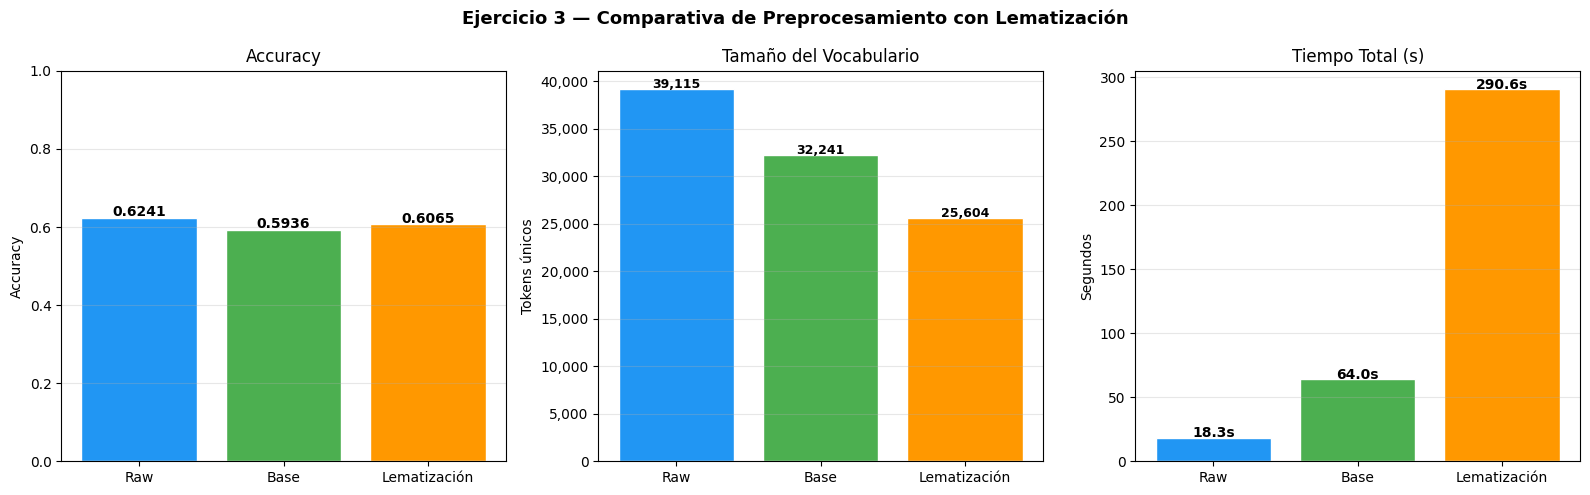


  Análisis:
  • Mejor accuracy  : Sin preprocesamiento (raw) (0.6241)
  • Reducción vocab : 34.5% (raw → lematización)



In [ ]:
# ----------------------------------------------------------
# 3.4  Visualización
# ----------------------------------------------------------
print("\n Graficando...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ejercicio 3 — Comparativa de Preprocesamiento con Lematización',
             fontsize=13, fontweight='bold')

nombres_cortos = ['Raw', 'Base', 'Lematización']
colores3 = COLORS[:3]

# Accuracy
ax = axes[0]
bars = ax.bar(nombres_cortos, df_exp3['accuracy'], color=colores3, edgecolor='white')
ax.set_title('Accuracy'); ax.set_ylabel('Accuracy'); ax.set_ylim(0.0, 1.0)
for bar, a in zip(bars, df_exp3['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{a:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Vocabulario
ax = axes[1]
bars2 = ax.bar(nombres_cortos, df_exp3['vocab'], color=colores3, edgecolor='white')
ax.set_title('Tamaño del Vocabulario'); ax.set_ylabel('Tokens únicos')
for bar, v in zip(bars2, df_exp3['vocab']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)

# Tiempo de entrenamiento + vectorización
ax = axes[2]
bars3 = ax.bar(nombres_cortos, df_exp3['tiempo'], color=colores3, edgecolor='white')
ax.set_title('Tiempo Total (s)'); ax.set_ylabel('Segundos')
for bar, t in zip(bars3, df_exp3['tiempo']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ejercicio3_lematizacion.png', dpi=150)
plt.show()

# Análisis
mejor_exp3 = df_exp3.loc[df_exp3['accuracy'].idxmax()]
vocab_reduccion = (
    (df_exp3.loc[0,'vocab'] - df_exp3.loc[2,'vocab'])
    / df_exp3.loc[0,'vocab'] * 100
)
print(f"""
  Análisis:
  • Mejor accuracy  : {mejor_exp3['variante']} ({mejor_exp3['accuracy']:.4f})
  • Reducción vocab : {vocab_reduccion:.1f}% (raw → lematización)
""")

**¿La lematización mejora o empeora?**

  * En este caso reduce el accuracy levemente → Reduce el vocabulario sin perder información semántica.
  * El tiempo de procesamiento es mayor, por lo que en datasets más grandes puede suponer un coste computacional importante.
  * El costo computacional de spaCy puede no justificarse frente a una limpieza simple + min_df adecuado.

### Análisis de dispersión

#### 4.1 Tamaños de corpus

In [ ]:
import scipy.sparse as sp

# ----------------------------------------------------------
# 4.1  Preparar corpus completo mezclado
# ----------------------------------------------------------
print("\n Preparando corpus base...")

# Usamos el dataset completo
all_data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Mezclar aleatoriamente para no sesgar por categoría
rng = np.random.default_rng(42)
idx_shuffled = rng.permutation(len(all_data.data))
corpus_completo = [all_data.data[i] for i in idx_shuffled]

print(f"  Total de documentos disponibles: {len(corpus_completo):,}")

# Tamaños de corpus a evaluar
tamanos = [100, 500, 1_000, 5_000, 10_000]
print(f"  Tamaños a evaluar: {tamanos}")


 Preparando corpus base...
  Total de documentos disponibles: 18,846
  Tamaños a evaluar: [100, 500, 1000, 5000, 10000]


#### 4.2 Métricas de dispersión

In [ ]:
# ----------------------------------------------------------
# 4.2  Función para calcular métricas de dispersión
# ----------------------------------------------------------

def analizar_corpus(textos: list) -> dict:
    """
    Vectoriza un corpus con CountVectorizer y calcula:
    - Tamaño del vocabulario
    - Porcentaje de dispersión de la matriz
    - Memoria de la matriz dispersa (MB)
    - Memoria de la matriz densa equivalente (MB)

    Retorna un diccionario con las métricas.
    """
    vec = CountVectorizer(
        lowercase=True,
        stop_words='english',
        min_df=2,
        max_df=0.95
    )
    X_sparse = vec.fit_transform(textos)

    n_docs, n_terms = X_sparse.shape
    n_total_cells   = n_docs * n_terms
    n_nonzero        = X_sparse.nnz

    # Dispersión = proporción de celdas con valor 0
    dispersion = 1.0 - n_nonzero / n_total_cells

    # Memoria formato CSR (disperso): datos + índices de columna + punteros de fila
    mem_sparse_mb = (
        X_sparse.data.nbytes
        + X_sparse.indices.nbytes
        + X_sparse.indptr.nbytes
    ) / 1024**2

    # Memoria equivalente si fuera densa (float64)
    mem_dense_mb = (n_total_cells * 8) / 1024**2

    return {
        'n_docs'       : n_docs,
        'vocab_size'   : len(vec.vocabulary_),
        'n_terms'      : n_terms,
        'dispersion'   : dispersion * 100,
        'mem_sparse_mb': mem_sparse_mb,
        'mem_dense_mb' : mem_dense_mb,
        'razon_compresion': mem_dense_mb / mem_sparse_mb if mem_sparse_mb > 0 else 0,
        'nnz'          : n_nonzero,
        'n_total_cells': n_total_cells,
    }

#### 4.3 Análisis por tamaño

In [ ]:
print("\n Calculando métricas...\n")
print(f"  {'N docs':>8} {'Vocab':>10} {'Dispersión':>12} "
      f"{'Mem. Sparse':>13} {'Mem. Dense':>12} {'Ratio':>8}")
print(f"  {'-'*70}")

metricas = []
for n in tamanos:
    m = analizar_corpus(corpus_completo[:n])
    metricas.append({'n_docs': n, **m})
    print(f"  {n:>8,} {m['vocab_size']:>10,} {m['dispersion']:>11.2f}% "
          f"{m['mem_sparse_mb']:>11.2f} MB {m['mem_dense_mb']:>10.2f} MB "
          f"{m['razon_compresion']:>7.1f}x")

df_disp = pd.DataFrame(metricas)


 Calculando métricas...

    N docs      Vocab   Dispersión   Mem. Sparse   Mem. Dense    Ratio
  ----------------------------------------------------------------------
       100        980       96.66%        0.04 MB       0.75 MB    19.7x
       500      4,326       98.93%        0.27 MB      16.50 MB    61.8x
     1,000      7,595       99.32%        0.60 MB      57.95 MB    97.2x
     5,000     22,945       99.75%        3.35 MB     875.28 MB   261.5x
    10,000     35,568       99.83%        6.98 MB    2713.62 MB   388.6x


#### 4.4 Visualización


 Graficando métricas de dispersión...


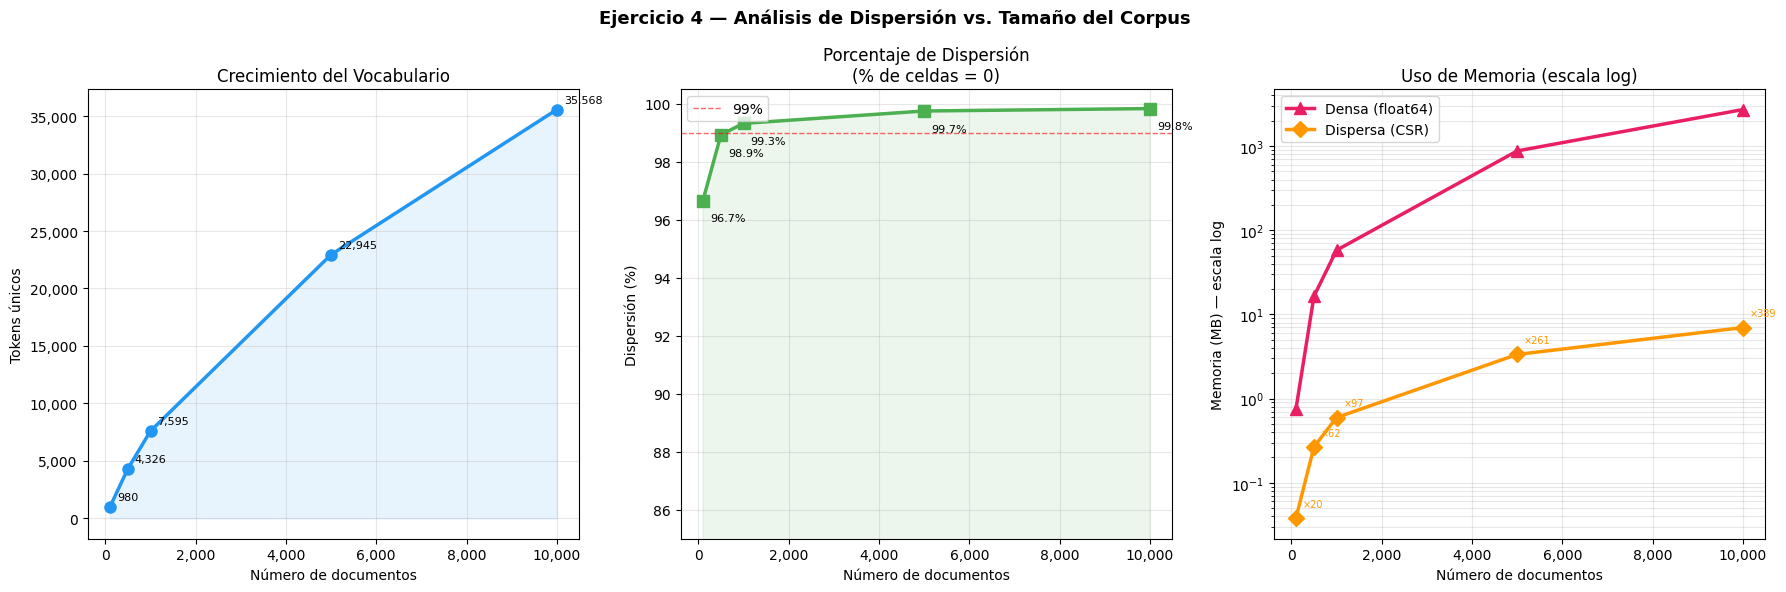

In [ ]:
# ----------------------------------------------------------
# 4.4  Visualización de las tres métricas
# ----------------------------------------------------------
print("\n Graficando métricas de dispersión...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ejercicio 4 — Análisis de Dispersión vs. Tamaño del Corpus',
             fontsize=13, fontweight='bold')

# ── Subplot 1: Crecimiento del vocabulario ──
ax = axes[0]
ax.plot(df_disp['n_docs'], df_disp['vocab_size'],
        'o-', color=COLORS[0], linewidth=2.5, markersize=8)
ax.fill_between(df_disp['n_docs'], df_disp['vocab_size'], alpha=0.1, color=COLORS[0])
ax.set_title('Crecimiento del Vocabulario')
ax.set_xlabel('Número de documentos')
ax.set_ylabel('Tokens únicos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for x, y in zip(df_disp['n_docs'], df_disp['vocab_size']):
    ax.annotate(f'{y:,}', xy=(x, y), xytext=(5, 5),
                textcoords='offset points', fontsize=8)
ax.grid(alpha=0.3)

# ── Subplot 2: Porcentaje de dispersión ──
ax = axes[1]
ax.plot(df_disp['n_docs'], df_disp['dispersion'],
        's-', color=COLORS[1], linewidth=2.5, markersize=8)
ax.fill_between(df_disp['n_docs'], df_disp['dispersion'], alpha=0.1, color=COLORS[1])
ax.axhline(y=99, color='red', linestyle='--', linewidth=1, alpha=0.6, label='99%')
ax.set_title('Porcentaje de Dispersión\n(% de celdas = 0)')
ax.set_xlabel('Número de documentos')
ax.set_ylabel('Dispersión (%)')
ax.set_ylim(85, 100.5)
for x, y in zip(df_disp['n_docs'], df_disp['dispersion']):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(5, -15),
                textcoords='offset points', fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(); ax.grid(alpha=0.3)

# ── Subplot 3: Memoria (dispersa vs. densa) ──
ax = axes[2]
ax.semilogy(df_disp['n_docs'], df_disp['mem_dense_mb'],
            '^-', color=COLORS[3], linewidth=2.5, markersize=8, label='Densa (float64)')
ax.semilogy(df_disp['n_docs'], df_disp['mem_sparse_mb'],
            'D-', color=COLORS[2], linewidth=2.5, markersize=8, label='Dispersa (CSR)')
ax.set_title('Uso de Memoria (escala log)')
ax.set_xlabel('Número de documentos')
ax.set_ylabel('Memoria (MB) — escala log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(); ax.grid(alpha=0.3, which='both')
# Anotar el ratio de compresión
for _, row in df_disp.iterrows():
    ax.annotate(
        f"×{row['razon_compresion']:.0f}",
        xy=(row['n_docs'], row['mem_sparse_mb']),
        xytext=(5, 8), textcoords='offset points', fontsize=7, color=COLORS[2]
    )

plt.tight_layout()
plt.savefig('ejercicio4_dispersion.png', dpi=150)
plt.show()

#### 4.5 Escalabilidad

In [ ]:
# ----------------------------------------------------------
# 4.5  Análisis de escalabilidad
# ----------------------------------------------------------
print("\n Análisis de escalabilidad:")
print(f"  {'N docs':>8} {'Vocab ×':>10} {'Dispersión':>12} {'Ratio compresión':>18}")
print(f"  {'-'*52}")

base_vocab = df_disp.iloc[0]['vocab_size']
for _, row in df_disp.iterrows():
    factor = row['vocab_size'] / base_vocab
    print(f"  {row['n_docs']:>8,} {factor:>10.1f}x {row['dispersion']:>11.2f}% "
          f"  {row['razon_compresion']:>14.0f}x")


 Análisis de escalabilidad:
    N docs    Vocab ×   Dispersión   Ratio compresión
  ----------------------------------------------------
     100.0        1.0x       96.66%               20x
     500.0        4.4x       98.93%               62x
   1,000.0        7.8x       99.32%               97x
   5,000.0       23.4x       99.75%              261x
  10,000.0       36.3x       99.83%              389x


**Conclusiones:**
* El vocabulario crece de forma sublineal (ley de Heaps/Zipf):
    duplicar el corpus no duplica el vocabulario.
* La dispersión aumenta con el corpus porque cada nuevo doc
    solo activa una fracción diminuta del vocabulario total.
* El formato disperso (CSR) puede comprimir >100x la memoria
    de la representación densa; para corpus grandes es esencial.
* A partir de 1k documentos, la dispersión supera el 99%:
    nunca usar matrices densas con corpus grandes.

### BoW vs Embeddings

In [ ]:
from sklearn.datasets import load_iris
!pip install gensim
import gensim.downloader as api

#### 5.1 Carga de modelo

In [ ]:
# ----------------------------------------------------------
# 5.1  Cargar modelo de embeddings preentrenado
# ----------------------------------------------------------
print("\n Cargando embeddings FastText...")
try:
    ft_model = api.load('fasttext-wiki-news-subwords-300')
    EMBEDDING_DIM = 300
    print(f"  FastText cargado. Dimensión: {EMBEDDING_DIM}")
    EMBEDDINGS_DISPONIBLES = True
except Exception as e:
    print(f"  No se pudo cargar FastText: {e}")
    print("Usando embeddings aleatorios como fallback (solo para demo de estructura)")
    EMBEDDINGS_DISPONIBLES = False
    EMBEDDING_DIM = 50


 Cargando embeddings FastText...
  FastText cargado. Dimensión: 300


#### 5.2 Vectorización con embeddings

In [ ]:
# ----------------------------------------------------------
# 5.2  Función para vectorizar con embeddings promediados
# ----------------------------------------------------------

def texto_a_embedding(texto: str, model, dim: int = 300) -> np.ndarray:
    """
    Convierte un texto en un vector de embeddings promediando
    los vectores de cada token del vocabulario del modelo.

    Si ningún token del texto existe en el modelo, devuelve
    un vector de ceros.

    Parámetros
    ----------
    texto : str  — texto a vectorizar
    model : KeyedVectors (gensim)
    dim   : int  — dimensión del embedding

    Retorna
    -------
    np.ndarray de forma (dim,)
    """
    tokens = texto.lower().split()
    vectores = []
    for token in tokens:
        if EMBEDDINGS_DISPONIBLES and token in model:
            vectores.append(model[token])
        elif not EMBEDDINGS_DISPONIBLES:
            # Fallback: embedding pseudoaleatorio por hash del token
            rng_t = np.random.RandomState(abs(hash(token)) % (2**31))
            vectores.append(rng_t.randn(dim).astype(np.float32))
    if vectores:
        return np.mean(vectores, axis=0)
    else:
        return np.zeros(dim, dtype=np.float32)


def corpus_a_embeddings(textos: list, model, dim: int = 300) -> np.ndarray:
    """Vectoriza una lista de textos; devuelve matriz (N, dim)."""
    return np.vstack([texto_a_embedding(t, model, dim) for t in textos])

#### 5.3 Datasets distintos

In [ ]:
# ----------------------------------------------------------
# 5.3  Preparar los 3 datasets
# ----------------------------------------------------------
print("\n Preparando los 3 datasets...\n")

# ── Dataset 1: 20 Newsgroups CIENCIA (tópicos distintos, texto largo) ──
cats_ciencia = ['sci.med', 'sci.space', 'sci.electronics', 'sci.crypt']
ng_train_1 = fetch_20newsgroups(subset='train', categories=cats_ciencia,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)
ng_test_1  = fetch_20newsgroups(subset='test',  categories=cats_ciencia,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)

# ── Dataset 2: 20 Newsgroups POLÍTICA (tópicos parecidos, más difícil) ──
cats_politica = ['talk.politics.guns', 'talk.politics.mideast',
                 'talk.politics.misc', 'talk.religion.misc']
ng_train_2 = fetch_20newsgroups(subset='train', categories=cats_politica,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)
ng_test_2  = fetch_20newsgroups(subset='test',  categories=cats_politica,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)

# ── Dataset 3: 20 Newsgroups DEPORTES (2 clases, muy específicas) ──
cats_deporte = ['rec.sport.baseball', 'rec.sport.hockey']
ng_train_3 = fetch_20newsgroups(subset='train', categories=cats_deporte,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)
ng_test_3  = fetch_20newsgroups(subset='test',  categories=cats_deporte,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)

datasets = [
    {
        'nombre'         : 'DS1: 20NG Ciencia\n(4 tópicos distintos)',
        'nombre_corto'   : 'Ciencia (4 tópicos)',
        'tipo'           : 'Tópicos diferenciados',
        'X_train'        : ng_train_1.data, 'y_train': ng_train_1.target,
        'X_test'         : ng_test_1.data,  'y_test' : ng_test_1.target,
    },
    {
        'nombre'         : 'DS2: 20NG Política\n(4 tópicos similares)',
        'nombre_corto'   : 'Política (4 tópicos)',
        'tipo'           : 'Tópicos similares',
        'X_train'        : ng_train_2.data, 'y_train': ng_train_2.target,
        'X_test'         : ng_test_2.data,  'y_test' : ng_test_2.target,
    },
    {
        'nombre'         : 'DS3: 20NG Deportes\n(2 tópicos, muy esp.)',
        'nombre_corto'   : 'Deportes (2 tópicos)',
        'tipo'           : 'Clasificación binaria',
        'X_train'        : ng_train_3.data, 'y_train': ng_train_3.target,
        'X_test'         : ng_test_3.data,  'y_test' : ng_test_3.target,
    },
]

for ds in datasets:
    print(f"  {ds['nombre_corto']:<28} "
          f"Train: {len(ds['X_train']):>4,}  Test: {len(ds['X_test']):>4,}  "
          f"Clases: {len(set(ds['y_train']))}")


 Preparando los 3 datasets...

  Ciencia (4 tópicos)          Train: 2,373  Test: 1,579  Clases: 4
  Política (4 tópicos)         Train: 1,952  Test: 1,301  Clases: 4
  Deportes (2 tópicos)         Train: 1,197  Test:  796  Clases: 2


#### 5.4 BoW vs. Embeddings

In [ ]:
# ----------------------------------------------------------
# 5.4  Experimento: BoW vs. Embeddings en cada dataset
# ----------------------------------------------------------
print("\n Entrenando modelos (BoW + Embeddings)...\n")
print(f"  {'Dataset':<30} {'Método':<22} {'Accuracy':>10} {'Tiempo (s)':>12}")
print(f"  {'-'*78}")

resultados_exp5 = []

for ds in datasets:
    # ── Método A: BoW + TF-IDF + LogReg ──
    t0 = time.time()
    bow_pipe = Pipeline([
        ('vect', TfidfVectorizer(
            stop_words='english', min_df=2, max_df=0.95,
            ngram_range=(1, 2), sublinear_tf=True
        )),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    bow_pipe.fit(ds['X_train'], ds['y_train'])
    y_pred_bow = bow_pipe.predict(ds['X_test'])
    acc_bow    = accuracy_score(ds['y_test'], y_pred_bow)
    t_bow      = time.time() - t0
    vocab_bow  = len(bow_pipe.named_steps['vect'].vocabulary_)

    print(f"  {ds['nombre_corto']:<30} {'BoW + TF-IDF + LogReg':<22} "
          f"{acc_bow:>10.4f} {t_bow:>12.1f}")

    resultados_exp5.append({
        'dataset': ds['nombre_corto'], 'tipo': ds['tipo'],
        'metodo': 'BoW + TF-IDF', 'accuracy': acc_bow, 'tiempo': t_bow,
    })

    # ── Método B: Embeddings promediados + LogReg ──
    t0 = time.time()
    X_train_emb = corpus_a_embeddings(ds['X_train'], ft_model if EMBEDDINGS_DISPONIBLES else None, EMBEDDING_DIM)
    X_test_emb  = corpus_a_embeddings(ds['X_test'],  ft_model if EMBEDDINGS_DISPONIBLES else None, EMBEDDING_DIM)
    clf_emb = LogisticRegression(max_iter=1000, random_state=42)
    clf_emb.fit(X_train_emb, ds['y_train'])
    y_pred_emb = clf_emb.predict(X_test_emb)
    acc_emb    = accuracy_score(ds['y_test'], y_pred_emb)
    t_emb      = time.time() - t0

    etiqueta_emb = 'FastText avg + LogReg' if EMBEDDINGS_DISPONIBLES else 'Emb. random + LogReg'
    print(f"  {'':30} {etiqueta_emb:<22} "
          f"{acc_emb:>10.4f} {t_emb:>12.1f}")

    resultados_exp5.append({
        'dataset': ds['nombre_corto'], 'tipo': ds['tipo'],
        'metodo': etiqueta_emb, 'accuracy': acc_emb, 'tiempo': t_emb,
    })
    print()

df_exp5 = pd.DataFrame(resultados_exp5)


 Entrenando modelos (BoW + Embeddings)...

  Dataset                        Método                   Accuracy   Tiempo (s)
  ------------------------------------------------------------------------------
  Ciencia (4 tópicos)            BoW + TF-IDF + LogReg      0.8189          5.1
                                 FastText avg + LogReg      0.6612          5.7

  Política (4 tópicos)           BoW + TF-IDF + LogReg      0.7218          2.2
                                 FastText avg + LogReg      0.4996          2.7

  Deportes (2 tópicos)           BoW + TF-IDF + LogReg      0.9183          0.8
                                 FastText avg + LogReg      0.7274          0.5



#### 5.5 Visualización


 Graficando resultados comparativos...


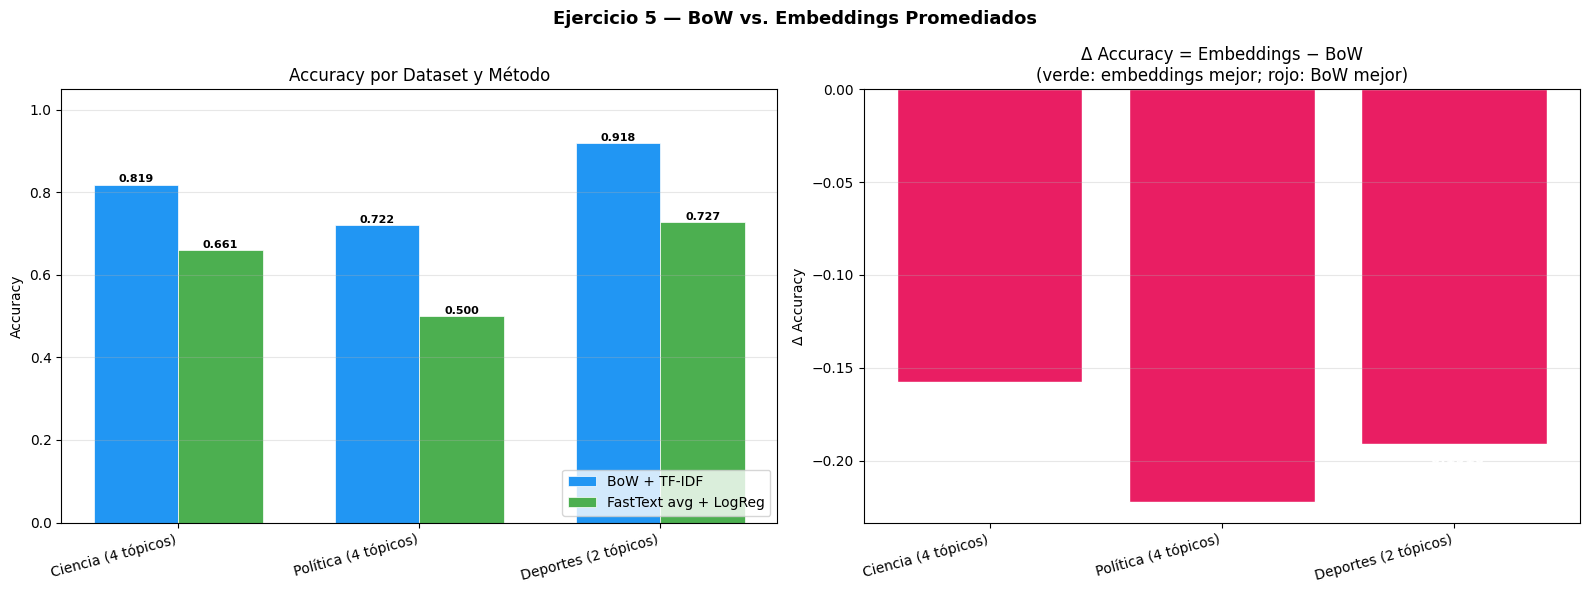

In [ ]:
# ----------------------------------------------------------
# 5.5  Visualización comparativa
# ----------------------------------------------------------
print("\n Graficando resultados comparativos...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ejercicio 5 — BoW vs. Embeddings Promediados',
             fontsize=13, fontweight='bold')

nombres_datasets = df_exp5['dataset'].unique()
metodos          = df_exp5['metodo'].unique()
x_pos            = np.arange(len(nombres_datasets))
width            = 0.35

# ── Subplot 1: Accuracy por dataset y método ──
ax = axes[0]
for i, metodo in enumerate(metodos):
    subset = df_exp5[df_exp5['metodo'] == metodo]
    bars = ax.bar(
        x_pos + i * width - width / 2,
        subset['accuracy'],
        width=width,
        label=metodo,
        color=COLORS[i],
        edgecolor='white', linewidth=0.5
    )
    for bar, acc in zip(bars, subset['accuracy']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontsize=8, fontweight='bold'
        )

ax.set_title('Accuracy por Dataset y Método')
ax.set_ylabel('Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres_datasets, rotation=15, ha='right')
ax.set_ylim(0.0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# ── Subplot 2: Diferencia relativa (Emb - BoW) ──
ax = axes[1]
# Calcular delta accuracy: Embeddings - BoW
datos_bow = df_exp5[df_exp5['metodo'].str.contains('BoW')].set_index('dataset')
datos_emb = df_exp5[~df_exp5['metodo'].str.contains('BoW')].set_index('dataset')
delta_acc = (datos_emb['accuracy'] - datos_bow['accuracy']).reindex(nombres_datasets)

colores_delta = [COLORS[1] if d >= 0 else COLORS[3] for d in delta_acc]
bars = ax.bar(nombres_datasets, delta_acc, color=colores_delta, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=1.2)
for bar, d in zip(bars, delta_acc):
    offset = 0.003 if d >= 0 else -0.010
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        d + offset,
        f'{d:+.4f}', ha='center', fontsize=10, fontweight='bold',
        color='white' if abs(d) > 0.01 else 'black'
    )
ax.set_title('Δ Accuracy = Embeddings − BoW\n(verde: embeddings mejor; rojo: BoW mejor)')
ax.set_ylabel('Δ Accuracy')
ax.set_xticks(np.arange(len(nombres_datasets)))
ax.set_xticklabels(nombres_datasets, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ejercicio5_bow_vs_embeddings.png', dpi=150)
plt.show()

**Conclusiones — BoW vs. Embeddings**

BoW ES COMPETITIVO cuando:
* La tarea depende de palabras clave concretas (clasificación de tópicos, detección de spam)
* Los documentos son largos (más contexto estadístico)
* El vocabulario de entrenamiento es representativo
* Se necesita velocidad e interpretabilidad

EMBEDDINGS SON SUPERIORES cuando:
* La tarea requiere comprensión semántica profunda (análisis de sentimiento, similitud semántica)
* Hay sinónimos o paráfrasis frecuentes
* Los documentos son cortos (tweets, reseñas)
* Clases semánticamente próximas (política ≈ religión)

VEREDICTO:
* Para clasificación de tópicos con texto abundante, BoW + TF-IDF sigue siendo un baseline muy sólido y es difícil de superar con embeddings promediados crudos. Los transformers (BERT) sí superan BoW consistentemente.

#### Reporte Final

In [ ]:
# ----------------------------------------------------------
# 6.  Reporte final
# ----------------------------------------------------------
print("\n Reporte final:")
print(f"\n  {'Dataset':<30} {'BoW Acc':>9} {'Emb Acc':>9} {'Delta':>9} {'Ganador':>12}")
print(f"  {'-'*75}")

for ds_nombre in nombres_datasets:
    sub = df_exp5[df_exp5['dataset'] == ds_nombre]
    acc_b = sub[sub['metodo'].str.contains('BoW')]['accuracy'].values[0]
    acc_e = sub[~sub['metodo'].str.contains('BoW')]['accuracy'].values[0]
    delta = acc_e - acc_b
    ganador = "Embeddings ✔" if delta > 0.005 else ("BoW ✔" if delta < -0.005 else "Empate ≈")
    print(f"  {ds_nombre:<30} {acc_b:>9.4f} {acc_e:>9.4f} {delta:>+9.4f} {ganador:>12}")


 Reporte final:

  Dataset                          BoW Acc   Emb Acc     Delta      Ganador
  ---------------------------------------------------------------------------
  Ciencia (4 tópicos)               0.8189    0.6612   -0.1577        BoW ✔
  Política (4 tópicos)              0.7218    0.4996   -0.2221        BoW ✔
  Deportes (2 tópicos)              0.9183    0.7274   -0.1910        BoW ✔
